Study pairwise unit cross-correlation around ripples

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import xarray as xr
import itertools
import scipy as sp
import ISRUtilities as isru
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [2]:
def _laggedSpikeCrossCorr(session,regs=None,window=0.1,shift=-1,pairs=None,METHOD=0):
    # compute lagged cross-region pairwise unit correlation around ripple-peak times as (shuffle, region, lag) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,events=['InfraSlowRhythm/infraslowaval','ripples','deltaWaves'])
    regs = R.ids if regs is None else np.array(regs)
    reg_pair_idx = list(itertools.permutations(range(len(regs)),2)) if pairs is None else pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
    unit_range = {regs[i]: [R.spikes(regs[i])[:,1].min(),R.spikes(regs[i])[:,1].max()] if r else None for i, r in enumerate(is_reg)}
    rip_time = R.eventInfo('deltaWaves','peaks')

    #isr = R.eventInfo('slownr')
    #on = R.eventInfo('slowavalnr')
    #_, is_ok = fma.general.restrict(on[:,0]-.0001,isr,s_ind=True)
    #off_on = fma.general.restrict(on[is_ok,0],R.eventIntervals('sws')).ravel() # restrict in nREM to shuffle transitions
    #_, is_ok = fma.general.restrict(on[:,1]+.0001,isr,s_ind=True)
    #on_off = on[is_ok,1]

    # 1. count spikes in overlapping windows around event times
    n_strides = 7 # time resolution will be win_size / n_strides
    n_bins = 12
    limits = [-n_bins*window/2, n_bins*window/2]
    n_times = (n_bins-1) * n_strides + 1
    counts = {}
    peths = {}
    for j, r in enumerate(regs[is_reg]):
        peths[r], times, _ = fma.analysis.PETH(R.spikes(r)[:,0],rip_time,limits=limits,n_bins=n_bins,step=n_strides,groups=R.spikes(r)[:,1],g_range=unit_range[r],fast=True) # (n_ripples, n_lags, n_units)
        #m = sp.stats.rankdata(m,axis=1) # rank along transitions # FOR METHOD 2
        #counts[r] = m - m.mean(axis=1,keepdims=True) # center ranks

    # 2. first method: scipy spearmanr
    if METHOD == 0:
        spearman = np.full((2,len(reg_pairs),n_times),np.nan)
        for i, rp in enumerate(reg_pair_idx):
            if is_reg[rp[0]] and is_reg[rp[1]]:
                ref_peth = peths[regs[rp[0]]]
                for k in [0,1]:
                    # shuffle: roll across events
                    lagged_peth = np.roll(peths[regs[rp[1]]],shift=shift,axis=0) if k else peths[regs[rp[1]]]
                    n_keep_units = lagged_peth.shape[2] # used to recover the cross-correlation block in spearmanr output
                    for t in range(len(times)):
                        with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                            spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
                        spearman[k,i,t] = np.nanmean(np.abs(spr[:n_keep_units,n_keep_units:]))

    # 2. average pairwise cross correlation, observed and shifted
    elif METHOD == 1:
        spearman = np.full((2,len(reg_pairs),n_times),np.nan)
        for i, rp in enumerate(reg_pair_idx):
            if is_reg[rp[0]] and is_reg[rp[1]]:
                # prepare observed and shifted (along events) spike counts
                ref = np.tile(counts[regs[rp[0]]][:,n_times//2,:],(2,1,1)) # (2, n_ripples, n_units1), at lag 0 s
                lagged = np.stack([counts[regs[rp[1]]], np.roll(counts[regs[rp[1]]],shift=shift,axis=0)], axis=0) # (2, n_ripples, n_lags, n_units2)

                num = np.einsum('pnm,pnlk->pmlk',ref,lagged) # numerator: covariance across events
                ref_norm = np.linalg.norm(ref,axis=1) # (2, n_units1)
                lag_norm = np.linalg.norm(lagged,axis=1) # (2, n_lags, n_units2)

                with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                    spear = num / (ref_norm[:,:,None,None] * lag_norm[:,None,:,:]) # spear[p,i,l,j] is the Spearman correlation between ref_count[:,i] and counts[reg2][:,l,j] for real / shuffle
                # average across unit pairs
                spearman[:,i,:] = np.nanmean(spear,axis=(1,3))

    xdata = xr.DataArray(spearman,dims=('shuffle','region','lag'),coords={'shuffle': [False,True],'region': reg_pairs,'lag': times,'rat': int(R.rat)})

    return xdata

In [2]:
def _transitionCorr(session,regs=None,pairs=None,n_shuffle=0,verbose=False):
    # compute lagged cross-region pairwise unit correlation around ripple-peak times as (shuffle, region, lag) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states='sws',events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr','ripples'])
    regs = R.ids if regs is None else np.array(regs)
    reg_pair_idx = list(itertools.permutations(range(len(regs)),2)) if pairs is None else pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
    unit_range = {regs[i]: [R.spikes(regs[i])[:,1].min(),R.spikes(regs[i])[:,1].max()] if r else None for i, r in enumerate(is_reg)}

    # shuffle ripple times
    rip_time = R.eventInfo('ripples')[:,2]
    #isr = R.eventInfo('slownr')
    #on = R.eventInfo('slowavalnr')
    #_, is_ok = fma.general.restrict(on[:,0]-.0001,isr,s_ind=True)
    #off_on = fma.general.restrict(on[is_ok,0],R.eventIntervals('sws')).ravel() # restrict in nREM to shuffle transitions
    #_, is_ok = fma.general.restrict(on[:,1]+.0001,isr,s_ind=True)
    #on_off = on[is_ok,1]
    shuffled_rip_time = np.zeros((len(rip_time),n_shuffle+1)) # each column is a shuffle, first is observed
    shuffled_rip_time[:,0] = rip_time
    for i in range(n_shuffle):
        shuffled_rip_time[:,i+1] = fma.general.shuffleEvents(rip_time,intervals=R.eventIntervals('sws'))

    # analysis parameters
    win_size = 0.2
    n_strides = 7 # time resolution will be win_size / n_strides
    n_wins = 7
    limits = [-n_wins*win_size/2, n_wins*win_size/2] # could be [-0.7,0.7]
    n_times = (n_wins-1) * n_strides + 1
    counts = {}
    spearman = np.full((n_shuffle+1,len(reg_pairs),n_times),np.nan)
    chunk_size = 100
    for k in range(0,n_shuffle+1,chunk_size):
        verbose and print(f'chunk: {k}')

        # concatenate chunk
        this_times = shuffled_rip_time[:,k:k+chunk_size].ravel('F')
        this_chunk_size = len(this_times) // shuffled_rip_time.shape[0]

        # 1. count spikes in overlapping windows around event times, only for regions in R
        for j, r in enumerate(regs[is_reg]):
            m, times, _ = fma.analysis.PETH(R.spikes(r)[:,0],this_times,limits=limits,n_bins=n_wins,step=n_strides,groups=R.spikes(r)[:,1],g_range=unit_range[r],fast=True)
            counts[r] = m.reshape((this_chunk_size,len(rip_time),n_times,int(unit_range[r][1]-unit_range[r][0])+1)) # (chunk_size, n_ripples, n_lags, n_units)
            counts[r] = sp.stats.rankdata(counts[r],axis=1) # rank along transitions
            counts[r] = counts[r] - counts[r].mean(axis=1,keepdims=True) # center ranks
        verbose and print(f'done peth')

        # 2. average pairwise cross correlation
        for i, rp in enumerate(reg_pair_idx):
            if is_reg[rp[0]] and is_reg[rp[1]]:

                ref_centered = counts[regs[rp[0]]][:,:,n_times//2,:] # (chunk_size, n_transitions, n_units1), at lag 0 s
                lagged_centered = counts[regs[rp[1]]] # (chunk_size, n_transitions, n_lags, n_units2)

                num = np.einsum('pnm,pnlk->pmlk',ref_centered,lagged_centered) # numerator: covariance across transitions
                ref_norm = np.linalg.norm(ref_centered,axis=1) # (chunk_size, n_units1,)
                lag_norm = np.linalg.norm(lagged_centered,axis=1) # (chunk_size, n_lags, n_units2)

                with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                    spear = num / (ref_norm[:,:,None,None] * lag_norm[:,None,:,:]) # spear[p,i,l,j] is the Spearman correlation between ref_count[:,i] and counts[reg2][:,l,j] for shuffle p
                # average across unit pairs
                spearman[k:k+this_chunk_size,i,:] = np.nanmean(spear,axis=(1,3))
        verbose and print(f'done spear')

    xdata = xr.DataArray(spearman,dims=('shuffle','region','lag'),coords={'shuffle': [False] + [True]*n_shuffle,'region': reg_pairs,'lag': times})

    return xdata

In [10]:
# test one session
session = fma.data.readBatchFile(batch_file)[0][30]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,shift=5,window=0.05)

session: /mnt/hubel-data-140/karadoc/Rat004_20240319/Rat004_20240319.xml


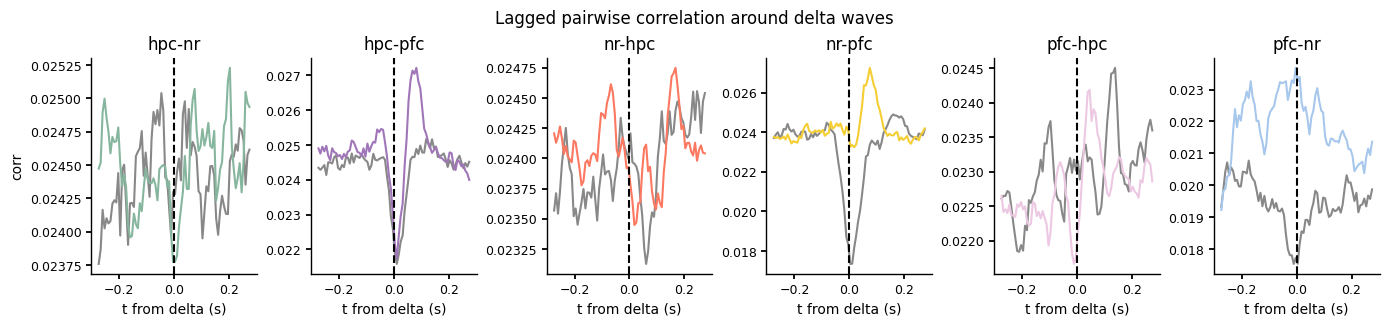

In [11]:
# interpretation: reg1 pop vector at transition correlated with reg2's delayed
fig, axs = fma.plotting.makeFigure('Lagged pairwise correlation around delta waves',[1,6],[35,8])
for i, r in enumerate(xdata['region']):
    reg_data = xdata.sel(region=r)
    fma.plotting.semPlot(xdata['lag'],reg_data.sel(shuffle=True),zscore=False,color=isru.paperColors('shuffle'),label=str(r.item().upper()),ax=axs[i])
    axs[i].plot(xdata['lag'],reg_data.sel(shuffle=False),color=isru.paperColors(i),label=str(r.item().upper()))
    axs[i].set_xlabel('t from delta (s)'), axs[i].set_title(r.values)
    axs[i].axvline(0,ls='--',color='k')
axs[0].set_ylabel('corr');

run batch

In [3]:
regs = ['hpc','nr','pfc']
xdata = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,kwargs={'regs': regs,'shift': -5,'window': 0.05},parallel=True)


Starting Batch, 2026-06-24 16:22:54.087376 



/tmp/ipykernel_2139819/1929545968.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
/tmp/ipykernel_2139819/1929545968.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
/tmp/ipykernel_2139819/1929545968.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
/tmp/ipykernel_2139819/1929545968.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
/tmp/ipykernel_2139819/1929545968.py:45: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearman

Error in session /mnt/hubel-data-131/perceval/Rat003_20231214/Rat003_20231214.xml (2)
'float' object is not subscriptable
Traceback:
Error in session /mnt/hubel-data-131/perceval/Rat003_20231218/Rat003_20231218.xml (4)
'float' object is not subscriptable
Traceback:
Error in session /mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml (5)
'float' object is not subscriptable
Traceback:
Error in session /mnt/hubel-data-131/perceval/Rat003_20231221/Rat003_20231221.xml (6)
'float' object is not subscriptable
Traceback:
Error in session /mnt/hubel-data-131/perceval/Rat003_20231223/Rat003_20231223.xml (8)
'float' object is not subscriptable
Traceback:
Error in session /mnt/hubel-data-139/perceval/Rat003_20231229/Rat003_20231229.xml (13)
'float' object is not subscriptable
Traceback:
Error in session /mnt/hubel-data-139/karadoc/Rat004_20240228/Rat004_20240228.xml (16)
'float' object is not subscriptable
Traceback:
Error in session /mnt/hubel-data-140/karadoc/Rat004_20240305/Rat004_

In [5]:
# concatenate data
data_cat = xr.concat([d for d in xdata if d is not None],dim='rat',join='outer')
data_avg = data_cat.groupby('rat').mean(dim='rat',skipna=True)
# grand-average statistical test MISSING shuffle=True !!!
#pval = {r.item(): fma.analysis.maxStatisticTest(data_cat.sel(region=r,shuffle=False),data_cat.sel(region=r).transpose('session','lag',...)) for r in data_cat.region}

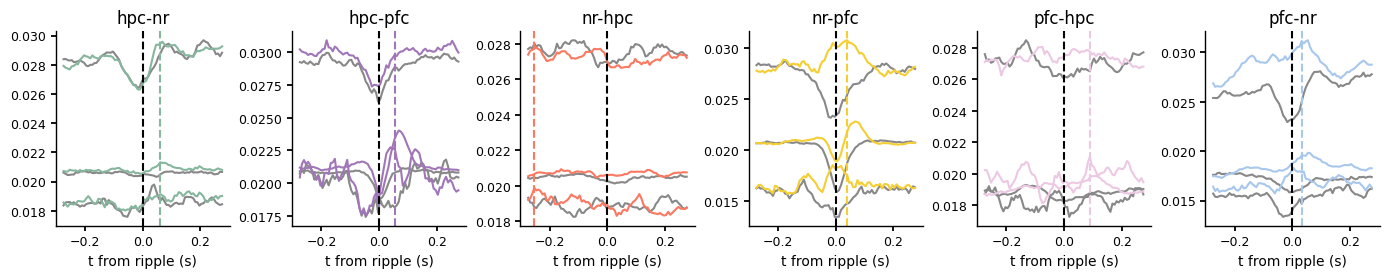

In [18]:
# Figure 2? DIVIDE ISA nISA
fig, axs = fma.plotting.makeFigure('',[1,6],size=[35,7])
for i, r in enumerate(data_avg['region'].values):
    reg_data = data_avg.sel(region=r)
    #fma.plotting.semPlot(data_avg['lag'],reg_data.sel(shuffle=True),zscore=2,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    #fma.plotting.semPlot(data_avg['lag'],reg_data.sel(shuffle=False),zscore=2,color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    # sh_mean = reg_data.sel(shuffle=True).mean(dim='lag')
    # sh_std = reg_data.sel(shuffle=True).std(dim='lag')
    # axs[i].plot(data_avg['lag'],(reg_data.sel(shuffle=True).T-sh_mean)/sh_std,color=isru.paperColors('shuffle'),label=r.upper())
    # axs[i].plot(data_avg['lag'],(reg_data.sel(shuffle=False).T-sh_mean)/sh_std,color=isru.paperColors(i),label=r.upper())
    axs[i].plot(data_avg['lag'],reg_data.sel(shuffle=True).T,color=isru.paperColors('shuffle'),label=r.upper())
    axs[i].plot(data_avg['lag'],reg_data.sel(shuffle=False).T,color=isru.paperColors(i),label=r.upper())
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('rat').data)
    axs[i].axvline(reg_data.lag[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('t from ripple (s)'), axs[i].set_title(r)
    # statistical significance
    #fma.plotting.pHorzLine(pval[r],data_cat['lag'],color=isru.paperColors(i),ax=axs[i])
#fma.plotting.saveFigure(fig,froot/'Figure3/Fig3g_fr_rip',['svg','png'])

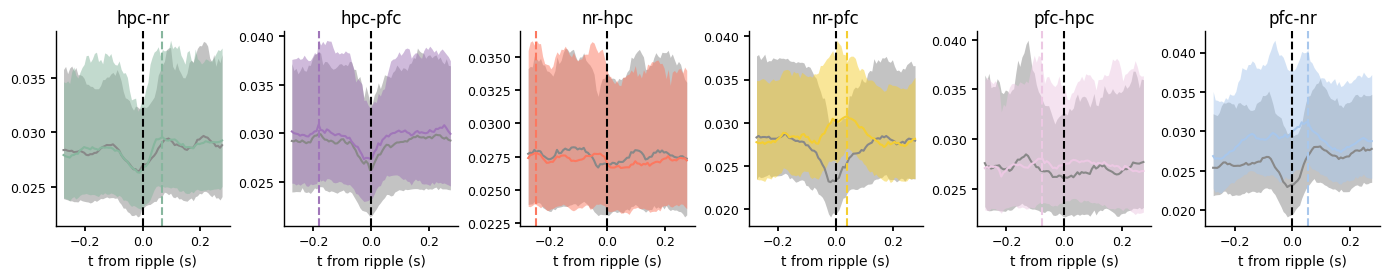

In [37]:
# see one rat
rat = 3
fig, axs = fma.plotting.makeFigure('',[1,6],size=[35,7])
for i, r in enumerate(data_cat['region'].values):
    reg_data = data_cat.sel(region=r,rat=rat)
    fma.plotting.semPlot(data_avg['lag'],reg_data.sel(shuffle=True),color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(data_avg['lag'],reg_data.sel(shuffle=False),color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('rat').data)
    axs[i].axvline(reg_data.lag[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('t from ripple (s)'), axs[i].set_title(r)

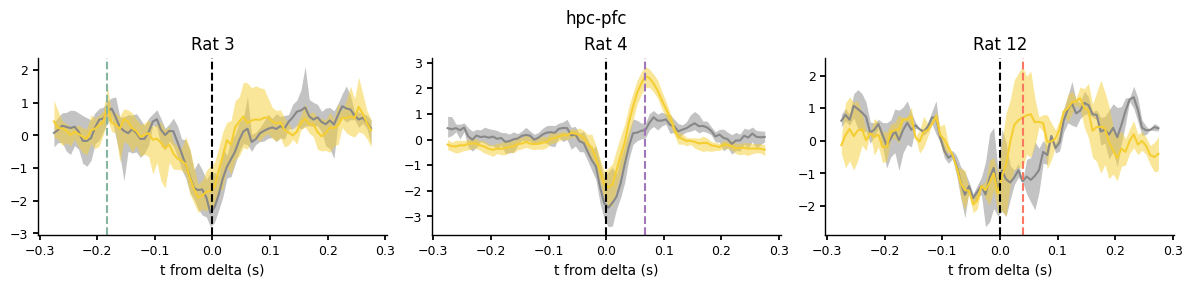

In [32]:
# see one region pair
r = 'hpc-pfc'
fig, axs = fma.plotting.makeFigure(r,[1,3],size=[30,7])
for i, rat in enumerate(data_avg['rat'].values):
    rat_data = data_cat.sel(region=r,rat=rat)
    fma.plotting.semPlot(data_avg['lag'],rat_data.sel(shuffle=True),zscore=2,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(data_avg['lag'],rat_data.sel(shuffle=False),zscore=2,color=isru.paperColors(r),label=r.upper(),ax=axs[i])
    peak_time = np.argmax(rat_data.sel(shuffle=False).mean('rat').data)
    axs[i].axvline(rat_data.lag[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('t from delta (s)'), axs[i].set_title(f'Rat {rat}')

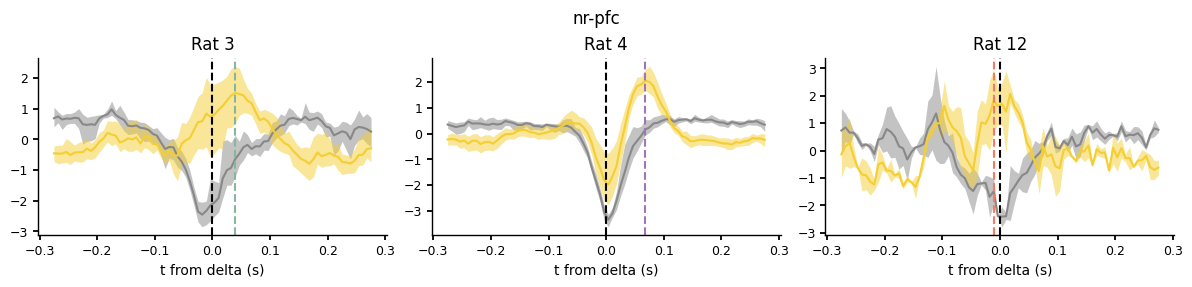

In [31]:
# see one region pair
r = 'hpc-pfc'
fig, axs = fma.plotting.makeFigure(r,[1,3],size=[30,7])
for i, rat in enumerate(data_avg['rat'].values):
    rat_data = data_cat.sel(region=r,rat=rat)
    fma.plotting.semPlot(data_avg['lag'],rat_data.sel(shuffle=True),zscore=2,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(data_avg['lag'],rat_data.sel(shuffle=False),zscore=2,color=isru.paperColors(r),label=r.upper(),ax=axs[i])
    peak_time = np.argmax(rat_data.sel(shuffle=False).mean('rat').data)
    axs[i].axvline(rat_data.lag[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('t from delta (s)'), axs[i].set_title(f'Rat {rat}')

Pspyke: su finestre temporali si pu﷿﷿﷿﷿﷿﷿ valutare nwueon-level correlazioni, magari intporno a ripples

Come H0 potrei guardare se momenti di burst in HPC senza ripples sono risultati simili